In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from state import BlogState
from agent import get_llm, researcher_agent

In [3]:
llm = get_llm()

In [4]:
outline = researcher_agent(llm=llm, topic="What is llm?", audience="Technical")

In [16]:
# print(outline)

In [5]:
from graph import build_blog_graph
from langgraph.types import Command

In [6]:
graph = build_blog_graph()

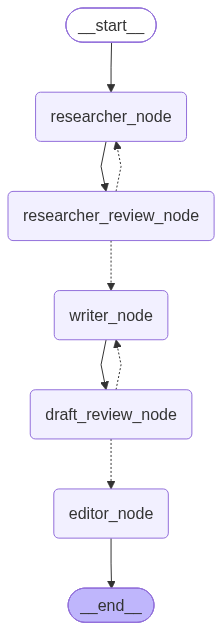

In [7]:
from IPython.display import Image

Image(graph.get_graph().draw_mermaid_png())

In [8]:
config = {"configurable": {"thread_id": "1"}}
state = graph.invoke(
    {
        "topic": "What is llm?",
        "audience": "technical",
    },
    config=config,
)

In [9]:
snap = graph.get_state(config)
interrupt_payload = snap.interrupts[0].value
print("Stage:", interrupt_payload.get("stage"))
print("Research:", interrupt_payload.get("research"))

Stage: researcher_review
Research: **Topic:** What is an LLM?
**Target Audience:** Technical (Developers, Data Scientists, Engineers)

### 1. Suggested Angle/Hook
**The "Beyond the Chatbot" Approach:** Move past the "AI that talks" narrative. Frame the LLM as a **probabilistic next-token prediction engine** based on high-dimensional vector spaces. The hook should focus on the transition from traditional NLP (rule-based/RNNs) to the Transformer architecture that enabled massive scalability.

---

### 2. Key Research Points & Supporting Data

*   **The Architectural Foundation: The Transformer**
    *   **Key Concepts:** Attention Mechanism (Self-Attention), Encoder-Decoder architecture, Positional Encoding.
    *   **Technical Detail:** Explain the "Attention is All You Need" (2017) paper; how it solved the vanishing gradient problem found in LSTMs/RNNs.
    *   **Example:** Contrast sequential processing (RNN) vs. parallel processing (Transformer).

*   **The Training Pipeline: From Pr

Approve the research


In [10]:
state = graph.invoke(
    Command(resume={"action": "approve", "feedback": ""}), config=config
)

In [11]:
snap = graph.get_state(config)
interrupt_payload = snap.interrupts[0].value
print("Stage:", interrupt_payload.get("stage"))
print("Draft:", interrupt_payload.get("draft"))

Stage: draft_review
Draft: # Beyond the Chatbot: A Technical Deep Dive into Large Language Models (LLMs)

When most people hear "LLM," they think of a polished chat interface that can write poetry or debug a Python script. But for developers and engineers, the "magic" is actually a sophisticated exercise in high-dimensional statistics. 

At its core, a Large Language Model is not "thinking"—it is a **probabilistic next-token prediction engine**. It operates by mapping linguistic patterns into a massive vector space to calculate the most likely sequence of characters to follow a given prompt. To understand how we got here, we have to look under the hood at the architecture that changed everything.

## The Engine: From RNNs to the Transformer
For years, Natural Language Processing (NLP) relied on Recurrent Neural Networks (RNNs) and LSTMs. These models processed text sequentially, which created a massive bottleneck: they struggled with "long-range dependencies" and suffered from vanishin

Approve the draft


In [12]:
state = graph.invoke(
    Command(resume={"action": "approve", "feedback": ""}), config=config
)

In [13]:
print(state["final_blog"])

# Beyond the Chatbot: A Technical Deep Dive into Large Language Models (LLMs)

When most people hear "LLM," they picture a polished chat interface that can write poetry or debug a Python script. But for developers and engineers, the "magic" is actually a sophisticated exercise in high-dimensional statistics.

At its core, a Large Language Model isn't "thinking"—it is a **probabilistic next-token prediction engine**. It operates by mapping linguistic patterns into a massive vector space to calculate the most likely sequence of characters to follow a given prompt. To understand how we got here, we have to look under the hood at the architecture that changed everything.

## The Engine: From RNNs to the Transformer
For years, Natural Language Processing (NLP) relied on Recurrent Neural Networks (RNNs) and LSTMs. These models processed text sequentially, which created a massive bottleneck: they struggled with "long-range dependencies" and frequently suffered from vanishing gradients.

The p

Review Flow or Human Feedback Flow


In [7]:
config = {"configurable": {"thread_id": "2"}}
state = graph.invoke(
    {
        "topic": "What is llm?",
        "audience": "technical",
    },
    config=config,
)

In [8]:
state = graph.invoke(
    Command(
        resume={
            "action": "update",
            "feedback": "change the topic to : 'Understanding the difference btw CSR, SSR, SSG and ISR?",
        }
    ),
    config=config,
)

In [9]:
print(state["research"])

**Topic:** Understanding the Difference Between CSR, SSR, SSG, and ISR
**Target Audience:** Technical (Developers/Architects)

### Suggested Angle/Hook
**"The Rendering Spectrum: Choosing the Right Strategy for Performance and SEO."**
Instead of just defining the terms, frame the blog as a decision-making guide. Position the choice not as "which is best," but as a trade-off between **TTFB (Time to First Byte)**, **FID (First Input Delay)**, and **Data Freshness**.

---

### Key Research Points

**1. Client-Side Rendering (CSR)**
*   **Core Concept:** The browser downloads a minimal HTML shell and a large JS bundle; JS then renders the content.
*   **Technical Details:** Heavy reliance on the DOM API; routing handled via History API.
*   **Pros/Cons:** Fast subsequent page transitions vs. poor SEO and slow initial load (FCP).
*   **Example:** A complex SaaS dashboard or a private user profile page.

**2. Server-Side Rendering (SSR)**
*   **Core Concept:** HTML is generated on the server

In [10]:
state = graph.invoke(
    Command(resume="I would like to continue to writing stage of blog now."),
    config=config,
)

In [13]:
print(state["draft"])

# The Rendering Spectrum: Choosing the Right Strategy for Performance and SEO

In the modern web ecosystem, the question is no longer "Should I use a framework?" but rather "Where should my HTML be generated?" 

For developers and architects, choosing a rendering strategy isn't about finding the "best" method—it's about managing trade-offs. Every decision you make impacts your **Time to First Byte (TTFB)**, **First Contentful Paint (FCP)**, and overall **SEO visibility**. Whether you are building a high-frequency trading dashboard or a static documentation site, understanding the rendering spectrum is critical to delivering a performant user experience.

## Client-Side Rendering (CSR): The App-Like Experience

Client-Side Rendering shifts the heavy lifting from the server to the user's browser. The server sends a minimal HTML shell and a large JavaScript bundle; the browser then executes that JS to build the DOM and fetch data via APIs.

**The Technical Trade-off:**
CSR relies heavily 

In [16]:
state = graph.invoke(
    Command(resume="Max length of blog should be 500 chars."),
    config=config,
)

In [17]:
print(state["draft"])

# The Rendering Spectrum: Choosing the Right Strategy for Performance and SEO

In modern web development, the question isn't "Which rendering method is best?" but rather "Which trade-off can my application afford?" As developers and architects, we are constantly balancing the tension between **Time to First Byte (TTFB)**, **First Contentful Paint (FCP)**, and **Data Freshness**.

Choosing the wrong strategy can lead to a sluggish user experience or a complete failure in SEO rankings. Let’s break down the rendering spectrum to help you make the right architectural decision.

## Client-Side Rendering (CSR): The App-Like Experience
CSR shifts the rendering burden to the browser. The server sends a minimal HTML shell and a large JavaScript bundle; the browser then executes that JS to build the DOM.

*   **The Technicals:** Heavy reliance on the DOM API and the History API for routing.
*   **The Trade-off:** You get lightning-fast subsequent page transitions, but at the cost of a slow initi

In [18]:
state = graph.invoke(
    Command(resume="cool, now finalize the blog"),
    config=config,
)

In [19]:
print(state["final_blog"])

# The Rendering Spectrum: Choosing the Right Strategy for Performance and SEO

In modern web development, the question isn't "Which rendering method is best?" but rather "Which trade-off can my application afford?" As developers and architects, we are constantly balancing the tension between **Time to First Byte (TTFB)**, **First Contentful Paint (FCP)**, and **Data Freshness**.

Choosing the wrong strategy can lead to a sluggish user experience or a complete collapse in SEO rankings. To make the right architectural decision, you need to understand where your project sits on the rendering spectrum.

## Client-Side Rendering (CSR): The App-Like Experience
CSR shifts the rendering burden entirely to the browser. The server sends a minimal HTML shell and a large JavaScript bundle; the browser then executes that JS to build the DOM.

*   **The Technicals:** Heavy reliance on the DOM API and the History API for routing.
*   **The Trade-off:** You get lightning-fast transitions between pages